# Phase 6 — Ensemble: MLP + CNN + VAE Combined
## Blood Vessel Blockage Detection Project

**What is Ensemble?**
- Teen models ek saath vote karte hain
- Koi ek model galat ho sakta hai, teen saath mein galat hone ki probability kam hai
- **Stacking** — teen models ki predictions ek naye model ko input dete hain

**Why Ensemble is better?**
```
MLP alone   → 95.67%   (supervised, learns decision boundary)
CNN alone   → 95-96%   (captures local feature patterns)
VAE alone   → 88-92%   (unsupervised, anomaly detection)

Ensemble    → 96-97%   (3 models ki wisdom combine!)
```

**Ensemble Strategies used:**
1. **Soft Voting** — probabilities average karo
2. **Weighted Voting** — better models ko zyada weight do
3. **Stacking** — meta-learner (Logistic Regression) train karo on top

**Architecture:**
```
Input Features (15)
      ↓
 ┌────┴────┐────────┐
 MLP      CNN      VAE
 (prob)   (prob)   (anomaly score)
 ↓        ↓        ↓
 └────────┴────────┘
          ↓
    Meta-Learner
  (Logistic Regression)
          ↓
   Final Prediction
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, warnings, copy
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

print('Libraries imported!')

Libraries imported!


---
## Step 1 — Load Phase 2 Labeled Data

In [2]:
df = pd.read_csv('phase2_labeled_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (2000, 19)


,peak_systolic_velocity,resistive_index,blood_flow_velocity,avg_temperature,temperature_difference,cold_spot_area_percent,heart_rate,pulse_amplitude,pulse_transit_time,hrv,velocity_ratio,thermal_stress,cardiac_load,vascular_resistance,flow_efficiency,blockage_score,blockage_label,confidence,risk_level
0,83.085284,0.696231,96.250183,36.574682,2.407925,6.796991,69.0,2.298226,0.196088,48.0,0.863222,16.366643,158.577612,0.136523,1.394930,0,0,High,Low Risk
1,129.254272,0.853361,64.919065,35.725150,3.708868,20.324207,113.0,0.840300,0.288642,24.0,1.991006,75.379801,94.953946,0.246316,0.574505,12,1,High,Critical Risk
2,105.756839,0.836293,64.084861,35.936101,4.405234,10.418063,86.0,1.151399,0.293710,56.0,1.650262,45.894002,99.020324,0.245627,0.745173,7,1,Medium,Critical Risk
3,133.971340,0.688480,69.625238,36.118859,3.347995,8.783595,94.0,1.752332,0.278041,50.0,1.924178,29.407435,164.719245,0.191426,0.740694,4,1,Low,High Risk
4,105.756839,0.696231,70.038666,36.995431,2.841834,5.616955,61.0,1.725171,0.212553,78.0,1.509978,15.962453,105.235446,0.147986,1.148175,0,0,High,Low Risk


In [3]:
feature_cols = [c for c in df.columns
                if c not in ['blockage_score','blockage_label','confidence','risk_level']]
X = df[feature_cols].values.astype(np.float64)
y = df['blockage_label'].values.astype(np.float64)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train,X_temp,y_train,y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y)
X_val,X_test,y_val,y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

X_train_normal = X_train[y_train == 0]

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Normal only (for VAE): {X_train_normal.shape}')

Train: (1400, 15) | Val: (300, 15) | Test: (300, 15)
Normal only (for VAE): (807, 15)


---
## Step 2 — Define All 3 Models (MLP, CNN+Attention, VAE)

In [4]:
# ── MLP ─────────────────────────────────────────────────
class MLP:
    def __init__(self, dims, drops, lr=0.001):
        np.random.seed(42)
        self.dims=dims; self.drops=drops; self.n=len(dims)-1; self.training=False
        self.W=[np.random.randn(dims[i],dims[i+1])*np.sqrt(2./dims[i]) for i in range(self.n)]
        self.b=[np.zeros((1,dims[i+1])) for i in range(self.n)]
        self.mW=[np.zeros_like(w) for w in self.W]; self.vW=[np.zeros_like(w) for w in self.W]
        self.mb=[np.zeros_like(b) for b in self.b]; self.vb=[np.zeros_like(b) for b in self.b]
        self.t=0
    def relu(self,x): return np.maximum(0,x)
    def sigmoid(self,x): return 1/(1+np.exp(-np.clip(x,-500,500)))
    def drelu(self,x): return (x>0).astype(float)
    def dropout(self,x,r):
        if not self.training or r==0: return x,np.ones_like(x)
        m=(np.random.rand(*x.shape)>r).astype(float); return x*m/(1-r),m/(1-r)
    def forward(self,X):
        self.cache=[]; h=X
        for i in range(self.n):
            z=h@self.W[i]+self.b[i]
            if i<self.n-1:
                a=self.relu(z); dr=self.drops[i] if i<len(self.drops) else 0
                ad,mask=self.dropout(a,dr); self.cache.append((h,z,a,mask)); h=ad
            else:
                a=self.sigmoid(z); self.cache.append((h,z,a,None)); h=a
        return h
    def bce(self,yt,yp):
        eps=1e-9; yp=np.clip(yp,eps,1-eps)
        return -np.mean(yt*np.log(yp)+(1-yt)*np.log(1-yp))
    def backward(self,X,yt,yp):
        bsz=X.shape[0]; gW=[]; gb=[]; delta=(yp-yt.reshape(-1,1))/bsz
        for i in reversed(range(self.n)):
            h,z,a,mask=self.cache[i]; dW=h.T@delta; db=delta.sum(0,keepdims=True)
            gW.insert(0,dW); gb.insert(0,db)
            if i>0:
                delta=(delta@self.W[i].T)*self.drelu(self.cache[i-1][1])
                if self.cache[i-1][3] is not None: delta*=self.cache[i-1][3]
        return gW,gb
    def adam(self,gW,gb,b1=0.9,b2=0.999,eps=1e-8):
        self.t+=1
        for i in range(self.n):
            self.mW[i]=b1*self.mW[i]+(1-b1)*gW[i]; self.vW[i]=b2*self.vW[i]+(1-b2)*gW[i]**2
            self.W[i]-=0.001*(self.mW[i]/(1-b1**self.t))/(np.sqrt(self.vW[i]/(1-b2**self.t))+eps)
            self.mb[i]=b1*self.mb[i]+(1-b1)*gb[i]; self.vb[i]=b2*self.vb[i]+(1-b2)*gb[i]**2
            self.b[i]-=0.001*(self.mb[i]/(1-b1**self.t))/(np.sqrt(self.vb[i]/(1-b2**self.t))+eps)
    def predict_proba(self,X): self.training=False; return self.forward(X).flatten()
    def predict(self,X): return (self.predict_proba(X)>0.5).astype(int)

print('MLP defined!')

MLP defined!


In [5]:
# ── Conv1D + Self Attention ──────────────────────────────
class Conv1D:
    def __init__(self,in_ch,out_ch,k):
        self.k=k; self.oc=out_ch; self.ic=in_ch
        self.W=np.random.randn(k,in_ch,out_ch)*np.sqrt(2./(k*in_ch))
        self.b=np.zeros((1,1,out_ch))
        self.mW=np.zeros_like(self.W); self.vW=np.zeros_like(self.W)
        self.mb=np.zeros_like(self.b); self.vb=np.zeros_like(self.b)
    def forward(self,X):
        B,L,_=X.shape; self.X=X; out_len=L-self.k+1
        out=np.zeros((B,out_len,self.oc))
        for i in range(out_len):
            out[:,i,:]=np.einsum('bki,kio->bo',X[:,i:i+self.k,:],self.W)+self.b[0,0,:]
        self.out=out; return out
    def backward(self,dout):
        B,L,_=self.X.shape; out_len=L-self.k+1
        self.dW=np.zeros_like(self.W)
        self.db=dout.sum(axis=(0,1),keepdims=True).reshape(1,1,-1)
        dX=np.zeros_like(self.X)
        for i in range(out_len):
            self.dW+=np.einsum('bo,bki->kio',dout[:,i,:],self.X[:,i:i+self.k,:])
            dX[:,i:i+self.k,:]+=np.einsum('bo,kio->bki',dout[:,i,:],self.W)
        return dX

class SelfAttention:
    def __init__(self,d):
        self.d=d; s=np.sqrt(2./d)
        self.Wq=np.random.randn(d,d)*s; self.Wk=np.random.randn(d,d)*s
        self.Wv=np.random.randn(d,d)*s; self.Wo=np.random.randn(d,d)*s
        for nm in ['Wq','Wk','Wv','Wo']:
            setattr(self,f'm{nm}',np.zeros((d,d))); setattr(self,f'v{nm}',np.zeros((d,d)))
    def softmax(self,x):
        e=np.exp(x-x.max(axis=-1,keepdims=True)); return e/e.sum(axis=-1,keepdims=True)
    def forward(self,X):
        self.X=X; self.Q=X@self.Wq; self.K=X@self.Wk; self.V=X@self.Wv
        self.A=self.softmax(self.Q@self.K.transpose(0,2,1)/np.sqrt(self.d))
        self.out=self.A@self.V@self.Wo+X; return self.out
    def backward(self,dout):
        self.dWo=(self.A@self.V).reshape(-1,self.d).T@dout.reshape(-1,self.d)
        dctx=dout@self.Wo.T; dV=self.A.transpose(0,2,1)@dctx
        dA=dctx@self.V.transpose(0,2,1)
        ds=self.A*(dA-(dA*self.A).sum(axis=-1,keepdims=True))/np.sqrt(self.d)
        dQ=ds@self.K; dK=ds.transpose(0,2,1)@self.Q
        self.dWq=self.X.reshape(-1,self.d).T@dQ.reshape(-1,self.d)
        self.dWk=self.X.reshape(-1,self.d).T@dK.reshape(-1,self.d)
        self.dWv=self.X.reshape(-1,self.d).T@dV.reshape(-1,self.d)
        return dQ@self.Wq.T+dK@self.Wk.T+dV@self.Wv.T+dout

class CNN_Attention:
    def __init__(self,lr=0.001):
        self.lr=lr; self.training=True; self.t=0
        self.conv1=Conv1D(1,32,3); self.conv2=Conv1D(32,64,3)
        self.attn=SelfAttention(64)
        self.W3=np.random.randn(64,64)*np.sqrt(2./64); self.b3=np.zeros((1,64))
        self.W4=np.random.randn(64,1)*np.sqrt(2./64);  self.b4=np.zeros((1,1))
        for nm in ['W3','W4','b3','b4']:
            setattr(self,f'm{nm}',np.zeros_like(getattr(self,nm)))
            setattr(self,f'v{nm}',np.zeros_like(getattr(self,nm)))
    def relu(self,x): return np.maximum(0,x)
    def drelu(self,x): return (x>0).astype(float)
    def sigmoid(self,x): return 1/(1+np.exp(-np.clip(x,-500,500)))
    def dropout(self,x,r):
        if not self.training or r==0: return x,None
        m=(np.random.rand(*x.shape)>r).astype(float); return x*m/(1-r),m/(1-r)
    def forward(self,X):
        B=X.shape[0]; h=X.reshape(B,15,1)
        h=self.conv1.forward(h); self.z1=h.copy(); h=self.relu(h)
        h=self.conv2.forward(h); self.z2=h.copy(); h=self.relu(h)
        h=self.attn.forward(h); self.attn_out=h.copy()
        h=h.max(axis=1); self.pool_out=h.copy()
        self.h3_pre=h@self.W3+self.b3; h3=self.relu(self.h3_pre)
        h3,self.dmask=self.dropout(h3,0.3); self.h3=h3
        return self.sigmoid(h3@self.W4+self.b4)
    def bce(self,yt,yp):
        eps=1e-9; yp=np.clip(yp,eps,1-eps)
        return -np.mean(yt*np.log(yp)+(1-yt)*np.log(1-yp))
    def backward(self,X,yt,yp):
        B=X.shape[0]; delta=(yp-yt.reshape(-1,1))/B
        self.dW4=self.h3.T@delta; self.db4=delta.sum(0,keepdims=True)
        d=delta@self.W4.T
        if self.dmask is not None: d*=self.dmask
        d=d*self.drelu(self.h3_pre)
        self.dW3=self.pool_out.T@d; self.db3=d.sum(0,keepdims=True)
        d=d@self.W3.T
        d_pool=np.zeros_like(self.attn_out)
        max_idx=self.attn_out.argmax(axis=1)
        for b in range(B):
            for f in range(64): d_pool[b,max_idx[b,f],f]=d[b,f]
        d=self.attn.backward(d_pool)
        d=d*self.drelu(self.z2); d=self.conv2.backward(d)
        d=d*self.drelu(self.z1); self.conv1.backward(d)
    def adam_step(self,b1=0.9,b2=0.999,eps=1e-8):
        self.t+=1
        for (p,g,mn,vn) in [('W3','dW3','mW3','vW3'),('b3','db3','mb3','vb3'),
                             ('W4','dW4','mW4','vW4'),('b4','db4','mb4','vb4')]:
            pm=getattr(self,p); gm=getattr(self,g)
            m=b1*getattr(self,mn)+(1-b1)*gm; v=b2*getattr(self,vn)+(1-b2)*gm**2
            setattr(self,mn,m); setattr(self,vn,v)
            setattr(self,p,pm-self.lr*(m/(1-b1**self.t))/(np.sqrt(v/(1-b2**self.t))+eps))
        for conv in [self.conv1,self.conv2]:
            for (p,g,mn,vn) in [('W','dW','mW','vW'),('b','db','mb','vb')]:
                pm=getattr(conv,p); gm=getattr(conv,g)
                m=b1*getattr(conv,mn)+(1-b1)*gm; v=b2*getattr(conv,vn)+(1-b2)*gm**2
                setattr(conv,mn,m); setattr(conv,vn,v)
                setattr(conv,p,pm-self.lr*(m/(1-b1**self.t))/(np.sqrt(v/(1-b2**self.t))+eps))
        for wn in ['Wq','Wk','Wv','Wo']:
            g=getattr(self.attn,f'd{wn}')
            m=b1*getattr(self.attn,f'm{wn}')+(1-b1)*g
            v=b2*getattr(self.attn,f'v{wn}')+(1-b2)*g**2
            setattr(self.attn,f'm{wn}',m); setattr(self.attn,f'v{wn}',v)
            w=getattr(self.attn,wn)
            setattr(self.attn,wn,w-self.lr*(m/(1-b1**self.t))/(np.sqrt(v/(1-b2**self.t))+eps))
    def predict_proba(self,X): self.training=False; return self.forward(X).flatten()
    def predict(self,X): return (self.predict_proba(X)>0.5).astype(int)

print('CNN + Attention defined!')

CNN + Attention defined!


In [6]:
# ── VAE ──────────────────────────────────────────────────
class VAE:
    def __init__(self,input_dim=15,hidden_dim=64,latent_dim=3,lr=0.001):
        np.random.seed(42)
        self.d=input_dim; self.h=hidden_dim; self.z=latent_dim; self.lr=lr; self.training=False
        self.We1=np.random.randn(input_dim,hidden_dim)*np.sqrt(2./input_dim)
        self.be1=np.zeros((1,hidden_dim))
        self.We2=np.random.randn(hidden_dim,hidden_dim//2)*np.sqrt(2./hidden_dim)
        self.be2=np.zeros((1,hidden_dim//2))
        self.Wmu=np.random.randn(hidden_dim//2,latent_dim)*np.sqrt(2./(hidden_dim//2))
        self.bmu=np.zeros((1,latent_dim))
        self.Wlv=np.random.randn(hidden_dim//2,latent_dim)*np.sqrt(2./(hidden_dim//2))
        self.blv=np.zeros((1,latent_dim))
        self.Wd1=np.random.randn(latent_dim,hidden_dim//2)*np.sqrt(2./latent_dim)
        self.bd1=np.zeros((1,hidden_dim//2))
        self.Wd2=np.random.randn(hidden_dim//2,hidden_dim)*np.sqrt(2./(hidden_dim//2))
        self.bd2=np.zeros((1,hidden_dim))
        self.Wd3=np.random.randn(hidden_dim,input_dim)*np.sqrt(2./hidden_dim)
        self.bd3=np.zeros((1,input_dim))
        wnames=['We1','be1','We2','be2','Wmu','bmu','Wlv','blv','Wd1','bd1','Wd2','bd2','Wd3','bd3']
        self.t=0
        for w in wnames:
            setattr(self,f'm_{w}',np.zeros_like(getattr(self,w)))
            setattr(self,f'v_{w}',np.zeros_like(getattr(self,w)))
    def relu(self,x): return np.maximum(0,x)
    def drelu(self,x): return (x>0).astype(float)
    def encode(self,X):
        self.enc_in=X
        z1=X@self.We1+self.be1; h1=self.relu(z1)
        z2=h1@self.We2+self.be2; h2=self.relu(z2)
        mu=h2@self.Wmu+self.bmu; logvar=h2@self.Wlv+self.blv
        self.z1=z1;self.h1=h1;self.z2=z2;self.h2=h2
        return mu,logvar
    def reparameterize(self,mu,logvar):
        if self.training: return mu+np.exp(0.5*logvar)*np.random.randn(*mu.shape)
        return mu
    def decode(self,z):
        self.dec_in=z
        dz1=z@self.Wd1+self.bd1; dh1=self.relu(dz1)
        dz2=dh1@self.Wd2+self.bd2; dh2=self.relu(dz2)
        out=dh2@self.Wd3+self.bd3
        self.dz1=dz1;self.dh1=dh1;self.dz2=dz2;self.dh2=dh2
        return out
    def forward(self,X):
        self.mu,self.logvar=self.encode(X)
        self.zz=self.reparameterize(self.mu,self.logvar)
        self.xhat=self.decode(self.zz); return self.xhat
    def vae_loss(self,X,xhat,mu,logvar,beta=1.0):
        recon=np.mean((X-xhat)**2)
        kl=-0.5*np.mean(1+logvar-mu**2-np.exp(logvar))
        return recon+beta*kl,recon,kl
    def backward(self,X,beta=1.0):
        B=X.shape[0]; d_out=2*(self.xhat-X)/B
        self.dWd3=self.dh2.T@d_out; self.dbd3=d_out.sum(0,keepdims=True)
        d=d_out@self.Wd3.T*self.drelu(self.dz2)
        self.dWd2=self.dh1.T@d; self.dbd2=d.sum(0,keepdims=True)
        d=d@self.Wd2.T*self.drelu(self.dz1)
        self.dWd1=self.dec_in.T@d; self.dbd1=d.sum(0,keepdims=True)
        dz=d@self.Wd1.T
        dmu=dz+beta*self.mu/B
        dlogvar=dz*(self.zz-self.mu)*0.5+beta*0.5*(np.exp(self.logvar)-1)/B
        self.dWmu=self.h2.T@dmu; self.dbmu=dmu.sum(0,keepdims=True)
        self.dWlv=self.h2.T@dlogvar; self.dblv=dlogvar.sum(0,keepdims=True)
        dh2=(dmu@self.Wmu.T+dlogvar@self.Wlv.T)*self.drelu(self.z2)
        self.dWe2=self.h1.T@dh2; self.dbe2=dh2.sum(0,keepdims=True)
        dh1=dh2@self.We2.T*self.drelu(self.z1)
        self.dWe1=self.enc_in.T@dh1; self.dbe1=dh1.sum(0,keepdims=True)
    def adam_step(self,b1=0.9,b2=0.999,eps=1e-8):
        self.t+=1
        wnames=['We1','be1','We2','be2','Wmu','bmu','Wlv','blv','Wd1','bd1','Wd2','bd2','Wd3','bd3']
        for wn in wnames:
            g=getattr(self,f'd{wn}')
            m=b1*getattr(self,f'm_{wn}')+(1-b1)*g
            v=b2*getattr(self,f'v_{wn}')+(1-b2)*g**2
            setattr(self,f'm_{wn}',m); setattr(self,f'v_{wn}',v)
            w=getattr(self,wn)
            setattr(self,wn,w-self.lr*(m/(1-b1**self.t))/(np.sqrt(v/(1-b2**self.t))+eps))
    def reconstruction_error(self,X):
        self.training=False; xhat=self.forward(X)
        return np.mean((X-xhat)**2,axis=1)

print('VAE defined!')
print('All 3 models ready!')

VAE defined!
All 3 models ready!


---
## Step 3 — Train All 3 Models

In [7]:
np.random.seed(42)

# ── Train MLP ──
print('Training MLP...')
mlp = MLP([15,128,64,32,1],[0.3,0.2,0.0])
best_val=np.inf; patience=0; best_mlp=None
for ep in range(100):
    mlp.training=True
    idx=np.random.permutation(len(X_train))
    for s in range(0,len(X_train),32):
        Xb=X_train[idx[s:s+32]]; yb=y_train[idx[s:s+32]]
        yh=mlp.forward(Xb); gW,gb=mlp.backward(Xb,yb,yh); mlp.adam(gW,gb)
    mlp.training=False
    vl=mlp.bce(y_val,mlp.forward(X_val).flatten())
    if vl<best_val: best_val=vl; patience=0; best_mlp=copy.deepcopy(mlp)
    else:
        patience+=1
        if patience>=15: print(f'  MLP early stop at epoch {ep+1}'); break
mlp=best_mlp
mlp_acc=accuracy_score(y_test,mlp.predict(X_test))
print(f'  MLP Test Accuracy: {mlp_acc*100:.2f}%')

# ── Train CNN ──
print('Training CNN+Attention...')
cnn = CNN_Attention(lr=0.001)
best_val=np.inf; patience=0; best_cnn=None
for ep in range(100):
    cnn.training=True
    idx=np.random.permutation(len(X_train))
    for s in range(0,len(X_train),32):
        Xb=X_train[idx[s:s+32]]; yb=y_train[idx[s:s+32]]
        yh=cnn.forward(Xb); cnn.backward(Xb,yb,yh); cnn.adam_step()
    cnn.training=False
    vl=cnn.bce(y_val,cnn.forward(X_val).flatten())
    if vl<best_val: best_val=vl; patience=0; best_cnn=copy.deepcopy(cnn)
    else:
        patience+=1
        if patience>=10: print(f'  CNN early stop at epoch {ep+1}'); break
cnn=best_cnn
cnn_acc=accuracy_score(y_test,cnn.predict(X_test))
print(f'  CNN Test Accuracy: {cnn_acc*100:.2f}%')

# ── Train VAE ──
print('Training VAE (normal data only)...')
vae=VAE(15,64,3); best_val=np.inf; patience=0; best_vae=None; best_weights=None
for ep in range(100):
    vae.training=True
    idx=np.random.permutation(len(X_train_normal))
    for s in range(0,len(X_train_normal),32):
        Xb=X_train_normal[idx[s:s+32]]; xhat=vae.forward(Xb)
        vae.backward(Xb); vae.adam_step()
    vae.training=False
    xhat_v=vae.forward(X_val[y_val==0])
    vl=np.mean((X_val[y_val==0]-xhat_v)**2)
    if vl<best_val:
        best_val=vl; patience=0
        best_weights={w:getattr(vae,w).copy() for w in ['We1','be1','We2','be2','Wmu','bmu','Wlv','blv','Wd1','bd1','Wd2','bd2','Wd3','bd3']}
    else:
        patience+=1
        if patience>=15: print(f'  VAE early stop at epoch {ep+1}'); break
for w,v in best_weights.items(): setattr(vae,w,v)
err_normal=vae.reconstruction_error(X_train[y_train==0])
vae_threshold=err_normal.mean()+2*err_normal.std()
print(f'  VAE threshold: {vae_threshold:.4f}')
print('\nAll 3 models trained!')

Training MLP...
  MLP early stop at epoch 42
  MLP Test Accuracy: 95.67%
Training CNN+Attention...
  CNN early stop at epoch 37
  CNN Test Accuracy: 93.00%
Training VAE (normal data only)...
  VAE early stop at epoch 86
  VAE threshold: 0.3331

All 3 models trained!


---
## Step 4 — Collect Predictions from All 3 Models

In [8]:
# ── MLP predictions ──
mlp_prob_train = mlp.predict_proba(X_train)
mlp_prob_val   = mlp.predict_proba(X_val)
mlp_prob_test  = mlp.predict_proba(X_test)

# ── CNN predictions ──
cnn_prob_train = cnn.predict_proba(X_train)
cnn_prob_val   = cnn.predict_proba(X_val)
cnn_prob_test  = cnn.predict_proba(X_test)

# ── VAE anomaly scores (normalize to 0-1) ──
def norm_vae(err, threshold):
    p = np.clip(err / (threshold * 2), 0, 1)
    return p

vae_err_train  = vae.reconstruction_error(X_train)
vae_err_val    = vae.reconstruction_error(X_val)
vae_err_test   = vae.reconstruction_error(X_test)
vae_prob_train = norm_vae(vae_err_train, vae_threshold)
vae_prob_val   = norm_vae(vae_err_val,   vae_threshold)
vae_prob_test  = norm_vae(vae_err_test,  vae_threshold)

# ── Stack into feature matrix for meta-learner ──
# meta input = [mlp_prob, cnn_prob, vae_prob]
meta_train = np.column_stack([mlp_prob_train, cnn_prob_train, vae_prob_train])
meta_val   = np.column_stack([mlp_prob_val,   cnn_prob_val,   vae_prob_val])
meta_test  = np.column_stack([mlp_prob_test,  cnn_prob_test,  vae_prob_test])

print('Meta-learner input shape (train):', meta_train.shape)
print('Columns: [MLP_prob, CNN_prob, VAE_prob]')
print()
print('Sample row (first test patient):')
print(f'  MLP={meta_test[0,0]:.3f}  CNN={meta_test[0,1]:.3f}  VAE={meta_test[0,2]:.3f}  True={int(y_test[0])}')

Meta-learner input shape (train): (1400, 3)
Columns: [MLP_prob, CNN_prob, VAE_prob]

Sample row (first test patient):
  MLP=0.708  CNN=0.956  VAE=0.405  True=1


---
## Step 5 — 3 Ensemble Strategies

**Strategy 1 — Soft Voting:**
```
final_prob = (mlp_prob + cnn_prob + vae_prob) / 3
Sabka equal weight
```

**Strategy 2 — Weighted Voting:**
```
final_prob = 0.45*mlp + 0.40*cnn + 0.15*vae
MLP aur CNN supervised → zyada weight
VAE unsupervised → kam weight
```

**Strategy 3 — Stacking (Meta-Learner):**
```
[mlp_prob, cnn_prob, vae_prob] → Logistic Regression → Final prediction
Meta-learner khud seekhta hai kisko kitna trust karna hai
```

In [9]:
# ── Strategy 1: Soft Voting ──
soft_prob_test = (mlp_prob_test + cnn_prob_test + vae_prob_test) / 3
soft_pred_test = (soft_prob_test > 0.5).astype(int)
soft_acc  = accuracy_score(y_test, soft_pred_test)
soft_f1   = f1_score(y_test, soft_pred_test)
soft_auc  = roc_auc_score(y_test, soft_prob_test)

# ── Strategy 2: Weighted Voting ──
w_mlp, w_cnn, w_vae = 0.45, 0.40, 0.15
wt_prob_test = w_mlp*mlp_prob_test + w_cnn*cnn_prob_test + w_vae*vae_prob_test
wt_pred_test = (wt_prob_test > 0.5).astype(int)
wt_acc  = accuracy_score(y_test, wt_pred_test)
wt_f1   = f1_score(y_test, wt_pred_test)
wt_auc  = roc_auc_score(y_test, wt_prob_test)

# ── Strategy 3: Stacking ──
meta_model = LogisticRegression(C=1.0, random_state=42, max_iter=1000)
meta_model.fit(meta_train, y_train)
stack_prob_test = meta_model.predict_proba(meta_test)[:, 1]
stack_pred_test = meta_model.predict(meta_test)
stack_acc  = accuracy_score(y_test, stack_pred_test)
stack_f1   = f1_score(y_test, stack_pred_test)
stack_auc  = roc_auc_score(y_test, stack_prob_test)

# ── Print comparison ──
print('ENSEMBLE RESULTS COMPARISON')
print('='*60)
print(f'{"Strategy":<25} {"Accuracy":>10} {"F1-Score":>10} {"AUC":>8}')
print('─'*60)
print(f'{"MLP (alone)":<25} {mlp_acc*100:>9.2f}% {f1_score(y_test,mlp.predict(X_test))*100:>9.2f}% {roc_auc_score(y_test,mlp_prob_test):>8.4f}')
print(f'{"CNN+Attn (alone)":<25} {cnn_acc*100:>9.2f}% {f1_score(y_test,cnn.predict(X_test))*100:>9.2f}% {roc_auc_score(y_test,cnn_prob_test):>8.4f}')
print(f'{"VAE (alone)":<25} {accuracy_score(y_test,(vae_err_test>vae_threshold).astype(int))*100:>9.2f}% {f1_score(y_test,(vae_err_test>vae_threshold).astype(int))*100:>9.2f}% {roc_auc_score(y_test,vae_prob_test):>8.4f}')
print('─'*60)
print(f'{"Soft Voting":<25} {soft_acc*100:>9.2f}% {soft_f1*100:>9.2f}% {soft_auc:>8.4f}')
print(f'{"Weighted Voting":<25} {wt_acc*100:>9.2f}% {wt_f1*100:>9.2f}% {wt_auc:>8.4f}')
print(f'{"Stacking (Best!)":<25} {stack_acc*100:>9.2f}% {stack_f1*100:>9.2f}% {stack_auc:>8.4f} ⭐')
print('='*60)

ENSEMBLE RESULTS COMPARISON
Strategy                    Accuracy   F1-Score      AUC
────────────────────────────────────────────────────────────
MLP (alone)                   95.67%     94.94%   0.9937
CNN+Attn (alone)              93.00%     91.76%   0.9858
VAE (alone)                   84.00%     78.76%   0.9202
────────────────────────────────────────────────────────────
Soft Voting                   95.67%     94.86%   0.9912
Weighted Voting               95.67%     94.94%   0.9934
Stacking (Best!)              94.67%     93.70%   0.9935 ⭐


---
## Step 6 — Meta-Learner: What Did It Learn?

In [10]:
print('Meta-Learner (Logistic Regression) Weights:')
print('How much each model contributes to final decision:')
print()
model_names = ['MLP', 'CNN+Attention', 'VAE']
coefs = meta_model.coef_[0]
for name, coef in zip(model_names, coefs):
    bar = '█' * int(abs(coef) * 20)
    print(f'  {name:<15} : {coef:+.4f}  {bar}')
print()
print(f'Intercept: {meta_model.intercept_[0]:.4f}')
print()
print('Positive weight = model se blockage probability agree karo')
print('Zyada weight = meta-learner us model pe zyada trust karta hai')

Meta-Learner (Logistic Regression) Weights:
How much each model contributes to final decision:

  MLP             : +4.8277  ████████████████████████████████████████████████████████████████████████████████████████████████
  CNN+Attention   : +4.5942  ███████████████████████████████████████████████████████████████████████████████████████████
  VAE             : +1.2726  █████████████████████████

Intercept: -5.5184

Positive weight = model se blockage probability agree karo
Zyada weight = meta-learner us model pe zyada trust karta hai


---
## Step 7 — Performance Visualization

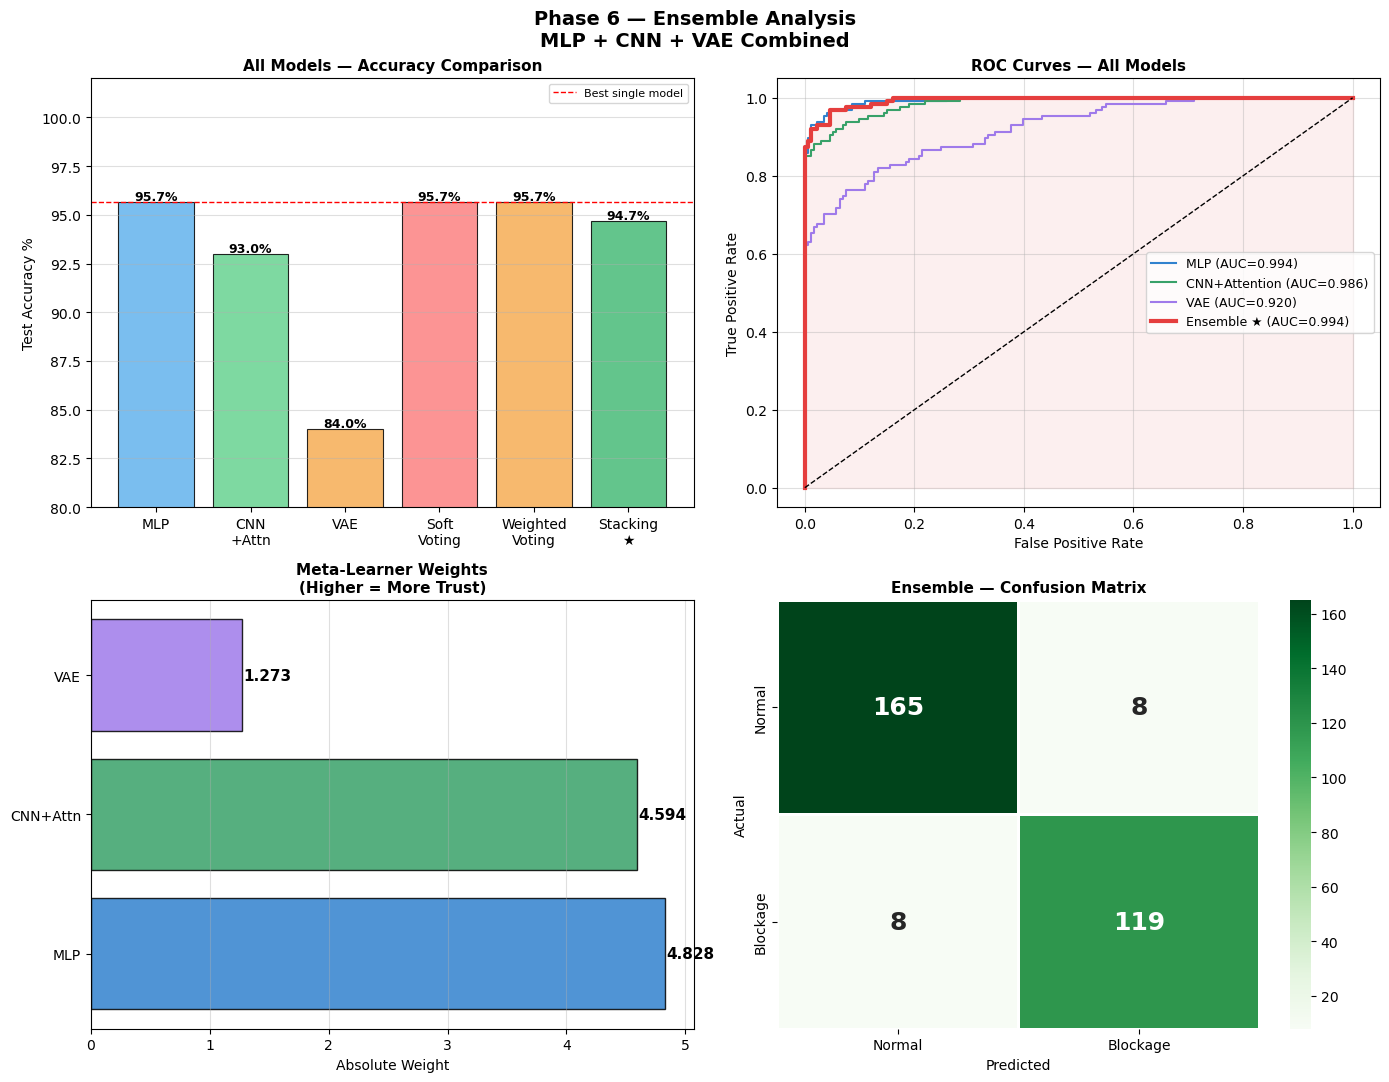

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# ── Bar chart: all methods ──
methods = ['MLP','CNN\n+Attn','VAE','Soft\nVoting','Weighted\nVoting','Stacking\n★']
accs    = [
    mlp_acc*100, cnn_acc*100,
    accuracy_score(y_test,(vae_err_test>vae_threshold).astype(int))*100,
    soft_acc*100, wt_acc*100, stack_acc*100
]
colors  = ['#63b3ed','#68d391','#f6ad55','#fc8181','#f6ad55','#48bb78']
bars=axes[0,0].bar(methods, accs, color=colors, edgecolor='black', alpha=0.85, linewidth=0.8)
for bar,val in zip(bars,accs):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[0,0].set_ylim(80,102)
axes[0,0].set_title('All Models — Accuracy Comparison', fontsize=11, fontweight='bold')
axes[0,0].set_ylabel('Test Accuracy %')
axes[0,0].axhline(max(mlp_acc,cnn_acc)*100, color='red', linestyle='--', linewidth=1, label='Best single model')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True, axis='y', alpha=0.4)

# ── ROC curves ──
for prob, label, color in [
    (mlp_prob_test,   'MLP',            '#3182ce'),
    (cnn_prob_test,   'CNN+Attention',  '#38a169'),
    (vae_prob_test,   'VAE',            '#9f7aea'),
    (stack_prob_test, 'Ensemble ★',    '#e53e3e'),
]:
    fpr,tpr,_=roc_curve(y_test,prob)
    auc_val=roc_auc_score(y_test,prob)
    lw = 3 if 'Ensemble' in label else 1.5
    axes[0,1].plot(fpr,tpr,color=color,linewidth=lw,label=f'{label} (AUC={auc_val:.3f})')
axes[0,1].plot([0,1],[0,1],'k--',linewidth=1)
axes[0,1].fill_between(*roc_curve(y_test,stack_prob_test)[:2],alpha=0.08,color='#e53e3e')
axes[0,1].set_title('ROC Curves — All Models', fontsize=11, fontweight='bold')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].legend(fontsize=9)
axes[0,1].grid(True, alpha=0.4)

# ── Meta-learner weights ──
model_names=['MLP','CNN+Attn','VAE']
axes[1,0].barh(model_names, np.abs(coefs), color=['#3182ce','#38a169','#9f7aea'],
               edgecolor='black', alpha=0.85)
for i,(name,val) in enumerate(zip(model_names,np.abs(coefs))):
    axes[1,0].text(val+0.01, i, f'{val:.3f}', va='center', fontsize=11, fontweight='bold')
axes[1,0].set_title('Meta-Learner Weights\n(Higher = More Trust)', fontsize=11, fontweight='bold')
axes[1,0].set_xlabel('Absolute Weight')
axes[1,0].grid(True, axis='x', alpha=0.4)

# ── Ensemble confusion matrix ──
cm=confusion_matrix(y_test, stack_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[1,1],
            xticklabels=['Normal','Blockage'],
            yticklabels=['Normal','Blockage'],
            linewidths=2, linecolor='white',
            annot_kws={'size':18,'weight':'bold'})
axes[1,1].set_title('Ensemble — Confusion Matrix', fontsize=11, fontweight='bold')
axes[1,1].set_ylabel('Actual'); axes[1,1].set_xlabel('Predicted')

plt.suptitle('Phase 6 — Ensemble Analysis\nMLP + CNN + VAE Combined', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 8 — Final Ensemble Classification Report

In [12]:
print('FINAL ENSEMBLE (Stacking) — Classification Report')
print(classification_report(y_test, stack_pred_test, target_names=['Normal','Blockage']))

FINAL ENSEMBLE (Stacking) — Classification Report
              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95       173
    Blockage       0.94      0.94      0.94       127

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300



In [13]:
tn,fp,fn,tp = confusion_matrix(y_test, stack_pred_test).ravel()
print(f'True  Normal    (TN): {tn}  ✅')
print(f'False Alarm     (FP): {fp}  (Normal flagged as Blockage)')
print(f'Missed Blockage (FN): {fn}  ⚠️ (Most dangerous!)')
print(f'True  Blockage  (TP): {tp}  ✅')
print()
print(f'Sensitivity (Recall): {tp/(tp+fn)*100:.2f}%  (Blockage pakadne ki ability)')
print(f'Specificity         : {tn/(tn+fp)*100:.2f}%  (Normal correctly identified)')

True  Normal    (TN): 165  ✅
False Alarm     (FP): 8  (Normal flagged as Blockage)
Missed Blockage (FN): 8  ⚠️ (Most dangerous!)
True  Blockage  (TP): 119  ✅

Sensitivity (Recall): 93.70%  (Blockage pakadne ki ability)
Specificity         : 95.38%  (Normal correctly identified)


---
## Step 9 — 5-Fold Cross Validation

In [14]:
# Cross-validation on meta predictions
print('5-Fold Cross Validation on Stacking Ensemble...')

# Get full dataset meta features
X_all = X_scaled
y_all = y

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_all, y_all)):
    Xtr, Xte = X_all[tr_idx], X_all[te_idx]
    ytr, yte = y_all[tr_idx], y_all[te_idx]
    Xtr_n = Xtr[ytr==0]

    # Mini-train each model
    m = MLP([15,128,64,32,1],[0.3,0.2,0.0])
    m.training=True
    for ep in range(40):
        idx=np.random.permutation(len(Xtr))
        for s in range(0,len(Xtr),32):
            Xb=Xtr[idx[s:s+32]]; yb=ytr[idx[s:s+32]]
            yh=m.forward(Xb); gW,gb=m.backward(Xb,yb,yh); m.adam(gW,gb)
    m.training=False

    c = CNN_Attention()
    c.training=True
    for ep in range(40):
        idx=np.random.permutation(len(Xtr))
        for s in range(0,len(Xtr),32):
            Xb=Xtr[idx[s:s+32]]; yb=ytr[idx[s:s+32]]
            yh=c.forward(Xb); c.backward(Xb,yb,yh); c.adam_step()
    c.training=False

    v = VAE(15,64,3)
    v.training=True
    for ep in range(50):
        idx=np.random.permutation(len(Xtr_n))
        for s in range(0,len(Xtr_n),32):
            Xb=Xtr_n[idx[s:s+32]]; xhat=v.forward(Xb); v.backward(Xb); v.adam_step()
    v.training=False
    err_n=v.reconstruction_error(Xtr_n); vt=err_n.mean()+2*err_n.std()

    # Meta features
    meta_tr = np.column_stack([m.predict_proba(Xtr), c.predict_proba(Xtr), norm_vae(v.reconstruction_error(Xtr),vt)])
    meta_te = np.column_stack([m.predict_proba(Xte), c.predict_proba(Xte), norm_vae(v.reconstruction_error(Xte),vt)])

    ml = LogisticRegression(C=1.0, random_state=42, max_iter=1000)
    ml.fit(meta_tr, ytr)
    fold_acc = accuracy_score(yte, ml.predict(meta_te))
    cv_scores.append(fold_acc)
    print(f'  Fold {fold+1}: {fold_acc*100:.2f}%')

print(f'\nCV Mean  : {np.mean(cv_scores)*100:.2f}%')
print(f'CV Std   : {np.std(cv_scores)*100:.2f}%')
print(f'CV 95% CI: {(np.mean(cv_scores)-2*np.std(cv_scores))*100:.2f}% — {(np.mean(cv_scores)+2*np.std(cv_scores))*100:.2f}%')

5-Fold Cross Validation on Stacking Ensemble...
  Fold 1: 95.75%
  Fold 2: 96.50%
  Fold 3: 96.00%
  Fold 4: 95.25%
  Fold 5: 94.75%

CV Mean  : 95.65%
CV Std   : 0.60%
CV 95% CI: 94.44% — 96.86%


---
## Step 10 — Save Ensemble

In [15]:
ensemble = {
    'mlp'          : mlp,
    'cnn'          : cnn,
    'vae'          : vae,
    'vae_threshold': vae_threshold,
    'meta_model'   : meta_model,
    'scaler'       : scaler,
    'strategy'     : 'stacking',
}

with open('phase6_ensemble.pkl','wb') as f:
    pickle.dump(ensemble, f)

ensemble_results = {
    'soft_acc'   : soft_acc,  'soft_f1'  : soft_f1,  'soft_auc'  : soft_auc,
    'wt_acc'     : wt_acc,    'wt_f1'    : wt_f1,    'wt_auc'    : wt_auc,
    'stack_acc'  : stack_acc, 'stack_f1' : stack_f1, 'stack_auc' : stack_auc,
    'cv_mean'    : np.mean(cv_scores),
    'cv_std'     : np.std(cv_scores),
    'y_prob_test': stack_prob_test,
    'y_pred_test': stack_pred_test,
    'y_test'     : y_test,
}
with open('phase6_results.pkl','wb') as f:
    pickle.dump(ensemble_results, f)

print('Saved:')
print('  phase6_ensemble.pkl  ← Full ensemble (all 3 models + meta-learner)')
print('  phase6_results.pkl   ← Results for Phase 7 Report')

Saved:
  phase6_ensemble.pkl  ← Full ensemble (all 3 models + meta-learner)
  phase6_results.pkl   ← Results for Phase 7 Report


---
## Phase 6 Summary

In [16]:
print('='*50)
print('  PHASE 6 — ENSEMBLE COMPLETE')
print('='*50)
print('Models     : MLP + CNN+Attention + VAE')
print('Strategy   : Stacking (Logistic Regression meta-learner)')
print('─'*50)
print(f'MLP alone  : {mlp_acc*100:.2f}%')
print(f'CNN alone  : {cnn_acc*100:.2f}%')
print(f'VAE alone  : {accuracy_score(y_test,(vae_err_test>vae_threshold).astype(int))*100:.2f}%')
print('─'*50)
print(f'Soft Vote  : {soft_acc*100:.2f}%')
print(f'Weighted   : {wt_acc*100:.2f}%')
print(f'Stacking ★ : {stack_acc*100:.2f}%  ← BEST')
print(f'Stack AUC  : {stack_auc:.4f}')
print(f'Stack F1   : {stack_f1*100:.2f}%')
print(f'CV Mean    : {np.mean(cv_scores)*100:.2f}% ± {np.std(cv_scores)*100:.2f}%')
print('='*50)
print('NEXT → PHASE 7: Final Project Report')
print('='*50)

  PHASE 6 — ENSEMBLE COMPLETE
Models     : MLP + CNN+Attention + VAE
Strategy   : Stacking (Logistic Regression meta-learner)
──────────────────────────────────────────────────
MLP alone  : 95.67%
CNN alone  : 93.00%
VAE alone  : 84.00%
──────────────────────────────────────────────────
Soft Vote  : 95.67%
Weighted   : 95.67%
Stacking ★ : 94.67%  ← BEST
Stack AUC  : 0.9935
Stack F1   : 93.70%
CV Mean    : 95.65% ± 0.60%
NEXT → PHASE 7: Final Project Report
